# Nearest Neighbour (KNN) Regression

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Load Data

In [2]:
# Load data
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
test_ids = test_df["id"].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
train_df.head()

Train shape: (630000, 13)
Test shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


### Preprocess

In [3]:
# Drop id
train_df = train_df.drop(columns=["id"])
test_df = test_df.drop(columns=["id"])

# Binary encode internet_access (numerical feature)
train_df["internet_access"] = train_df["internet_access"].map({"yes": 1, "no": 0})
test_df["internet_access"] = test_df["internet_access"].map({"yes": 1, "no": 0})

# Define feature types for ColumnTransformer (avoids data leakage during CV)
numerical_features = ["age", "study_hours", "class_attendance", "internet_access", "sleep_hours"]
categorical_features = [
    "gender", "course", "sleep_quality",
    "study_method", "facility_rating", "exam_difficulty",
]

target = "exam_score"
y = train_df[target]
X = train_df.drop(columns=[target])
X_submission = test_df[X.columns]

# Train/validation split for actual vs predicted plot
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Numerical: {numerical_features}")
print(f"Categorical: {categorical_features}")

Numerical: ['age', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours']
Categorical: ['gender', 'course', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [4]:
# Sample for tuning (full 630k is too slow for KNN CV)
SAMPLE_SIZE_TUNE = 50_000   # representative subset for GridSearchCV; final model uses full data

sample_idx = X_train.sample(n=min(SAMPLE_SIZE_TUNE, len(X_train)), random_state=42).index
X_tune = X_train.loc[sample_idx]
y_tune = y_train.loc[sample_idx]
print(f"Tuning on {len(X_tune):,} samples")

Tuning on 50,000 samples


In [5]:
# Preprocessing inside pipeline: numerical→StandardScaler, categorical→OneHotEncoder (no scaling of one-hot)
preprocess = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ],
    remainder="drop",
)

knn_model = Pipeline([
    ("preprocess", preprocess),
    ("knn", KNeighborsRegressor()),
])

cv = KFold(n_splits=3, shuffle=True, random_state=42)
param_grid = {
    "knn__n_neighbors": [5, 10, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    knn_model,
    param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_tune, y_tune)

print("\nBest params:", grid.best_params_)
print("Best CV RMSE (on tune sample):", round(-grid.best_score_, 4))
cv_results = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
cv_results["RMSE"] = -cv_results["mean_test_score"]
cv_results[["param_knn__n_neighbors", "param_knn__weights", "param_knn__metric", "RMSE"]].head(10)

Fitting 3 folds for each of 12 candidates, totalling 36 fits



Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
Best CV RMSE (on tune sample): 9.8578


,param_knn__n_neighbors,param_knn__weights,param_knn__metric,RMSE
5,15,distance,euclidean,9.857797
4,15,uniform,euclidean,9.874209
11,15,distance,manhattan,10.006527
3,10,distance,euclidean,10.029265
2,10,uniform,euclidean,10.040284
10,15,uniform,manhattan,10.041679
9,10,distance,manhattan,10.167830
8,10,uniform,manhattan,10.193735
1,5,distance,euclidean,10.570831
0,5,uniform,euclidean,10.573045


### Fit Final Model and Predict

In [6]:
# Fit best model on full training data (tuned on sample)
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)
print(f"Fitted final model on {len(X_train):,} samples")

# Predict on validation set (for actual vs predicted plot) and test set (for submission)
y_val_pred = best_model.predict(X_val)
y_pred = best_model.predict(X_submission)

# Validation metrics
rmse = np.sqrt(metrics.mean_squared_error(y_val, y_val_pred))
mae = metrics.mean_absolute_error(y_val, y_val_pred)
r2 = metrics.r2_score(y_val, y_val_pred)
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE:  {mae:.4f}")
print(f"Validation R²:   {r2:.4f}")

Fitted final model on 504,000 samples
Validation RMSE: 9.4681
Validation MAE:  7.5878
Validation R²:   0.7479


#### Residual Plot (Model diagnostics)

Residual = Actual − Predicted. This plot shows whether errors are random or biased. Random scatter around zero suggests good model fit; patterns indicate bias or heteroscedasticity.

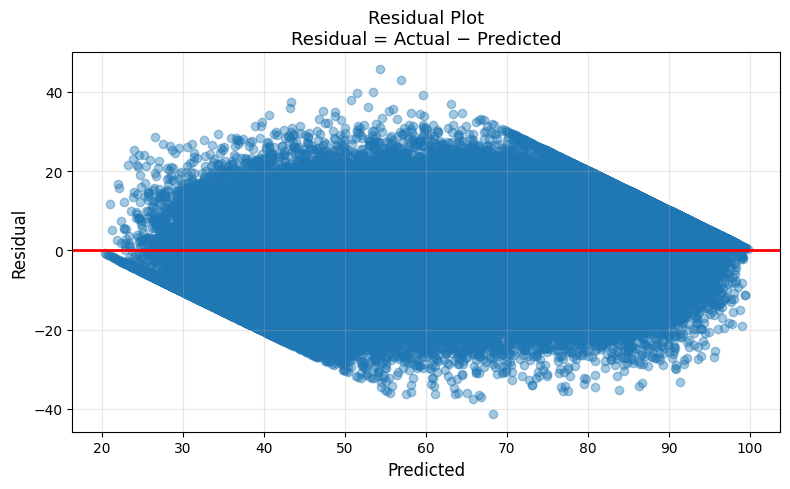

In [7]:
# Residual Plot: Residual = Actual − Predicted
# Shows whether errors are random or biased

residuals = y_val.values - y_val_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_val_pred, residuals, alpha=0.4)
plt.axhline(y=0, color="r", linestyle="-", linewidth=2)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Residual", fontsize=12)
plt.title("Residual Plot\nResidual = Actual − Predicted", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Submission saved to ../submission/nearest_neighbour_submission.csv
       id  exam_score
0  630000   66.699547
1  630001   72.828598
2  630002   83.458795
3  630003   53.861881
4  630004   52.738673


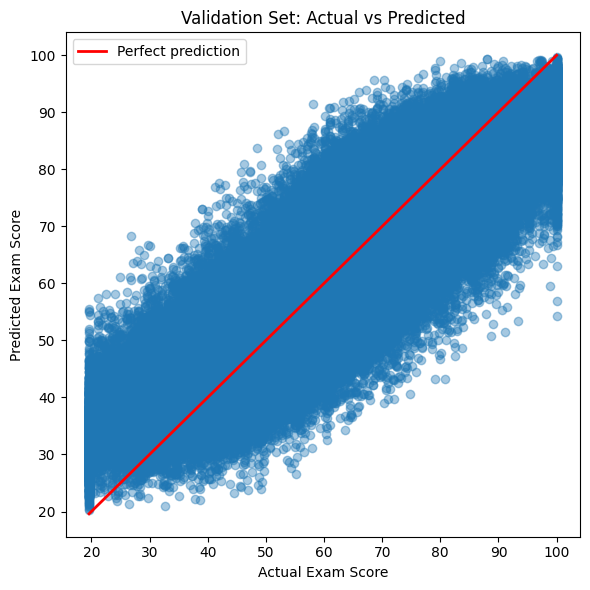

In [8]:
# Generate submission predictions
df_knn = pd.DataFrame({
    "id": test_ids,
    "exam_score": y_pred
})

out_dir = "../submission"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/nearest_neighbour_submission.csv"
df_knn.to_csv(out_path, index=False)
print(f"Submission saved to {out_path}")

print(df_knn.head())

# Actual vs Predicted (validation set)
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_val_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r", lw=2, label="Perfect prediction")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()